In [204]:
library("DESeq2")
library("ggplot2")
library("ggrepel")
library("ggcorrplot")
library("dplyr")
library(stringr)
library(purrr)
library("tibble")
library(dplyr)
library(tidyr)
library(ComplexHeatmap)
library("pals")
library(ggpubr)
library(tximport)
library(DESeq2)
library("apeglm")
library(patchwork)
library(ggrastr)
library(circlize)

theme_set(
    theme_classic(base_size = 12)
)
source('./plot_data.R')

In [205]:
final_iso_tb<- read.table("../data/2_final_iso_tb.tsv", sep = "\t", header = T)
length(unique(final_iso_tb$gene_id))
dim(final_iso_tb)[1]

# final number of annotated isoforms: 6292
# final number of annotated genes: 6016

# intron-containing genes
intron_genes<- final_iso_tb  %>% filter(blockCount > 1) %>% pull(gene_id) %>% sort() %>% unique()
final_iso_tb<- final_iso_tb %>% filter(gene_id %in% intron_genes)
length(unique(final_iso_tb$gene_id))
dim(final_iso_tb)[1]

# final number of annotated isoforms: 551
# final number of annotated genes: 275

[1] 6016

[1] 6292

[1] 275

[1] 551

In [244]:
count_all<- read.table(file = '../data/7_mature_rna_count.tsv', sep = "\t", header = T, row.names = 1, check.names = FALSE)

In [245]:
count<- read.table('../data/rna/matureRNA/isoquant/260121_teloprime_tx_alignment_annot_by_splicing_isoform_counts.tsv', header = TRUE, sep = "\t")

# reformat to same output with flair
count<- count %>% 
    mutate(iso_id = str_split_i(isoform, ":", 1)) %>% 
    mutate(gene_id = str_split_i(iso_id, "_", 1)) %>%
    mutate(iso = paste0(isoform, "_", gene_id)) %>%
    filter(gene_id %in% intron_genes) %>% 
    select(iso, ys18_rep1, ys18_rep2, ys18_rep3, ym209_rep1, ym209_rep2, ym209_rep3) %>% 
    arrange(iso) %>% 
    column_to_rownames(var= "iso") 

colnames(count)<- c("WT rep1", "WT rep2",  "WT rep3", "MUT rep1", "MUT rep2",  "MUT rep3")
RPK = count_all/1000
sc_factor = colSums(RPK)/ 1e6
tpm<- countToTPM(count, normalize_by_len = FALSE, scaling_factor = sc_factor)

write.table(x = count, file = '../data/13_mature_rna_splicing_count.tsv', sep = "\t", quote = FALSE, col.names = TRUE, row.names = TRUE)
write.table(x = tpm, file = '../data/13_mature_rna_splicing_tpm.tsv', sep = "\t", quote = FALSE, col.names = TRUE, row.names = TRUE)

## DESeq2

In [246]:
count<- read.table('../data/13_mature_rna_splicing_count.tsv', header = T, row.names = 1, sep = '\t')
tpm<- read.table('../data/13_mature_rna_splicing_tpm.tsv', header = T, row.names = 1, sep = '\t')

smallestGroupSize = 2
smallestCount = 10
keep <- rowSums(count >= smallestCount) >= smallestGroupSize
keep %>% table()
count<- count[keep, ]
tpm<-tpm[keep,]
n_genes<- length(str_split_i(rownames(tpm), ":", 1) %>% sort() %>% unique())
paste0("number of genes : ", n_genes) 
paste0("number of isoforms: ", dim(tpm)[1])

.
FALSE  TRUE 
  742   866 

[1] "number of genes : 254"

[1] "number of isoforms: 866"

In [247]:
coldata = data.frame(condition = str_split_i(colnames(count), "\\.", 1), batch = rep(1, ncol(count)))
coldata

rownames(coldata) = colnames(count)

dds <- DESeqDataSetFromMatrix(countData = count,
                              colData = coldata,
                              design = ~ condition)
dds
dds$condition <- relevel(dds$condition, ref = "WT")
dds <- DESeq(dds)
res <- results(dds)
resLFC <- lfcShrink(dds, coef="condition_MUT_vs_WT", type="apeglm")
deseq_tpm<- counts(dds, normalized = TRUE)
write.table(x = deseq_tpm, file = '../data/13_mature_rna_splicing_tpm_norm_by_deseq2.tsv', sep = "\t", quote = FALSE, col.names = TRUE, row.names = TRUE)

condition,batch
<chr>,<dbl>
WT,1
WT,1
WT,1
MUT,1
MUT,1
MUT,1


Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”


class: DESeqDataSet 
dim: 866 6 
metadata(1): version
assays(1): counts
rownames(866): ACT1:IR_ACT1 ACT1:downstream_ACT1 ...
  YSF3:intronicStart_YSF3 YSF3:spliced_YSF3
rowData names(0):
colnames(6): WT.rep1 WT.rep2 ... MUT.rep2 MUT.rep3
colData names(2): condition batch

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

using 'apeglm' for LFC shrinkage. If used in published research, please cite:
    Zhu, A., Ibrahim, J.G., Love, M.I. (2018) Heavy-tailed prior distributions for
    sequence count data: removing the noise and preserving large differences.
    Bioinformatics. https://doi.org/10.1093/bioinformatics/bty895



In [248]:
de_df<- analyzeDESeq(res, resLFC, final_iso_tb$gene_id, padj_cutoff = 0.05, log2fc_cutoff = 0.5, annot_down = 3, annot_up = 3)

In [309]:
iso_level<- de_df$feature_id %>% sort() %>% unique()

mcolors <- c("#5E8C61FF",
             "#FFC857FF",
             "#D0AF84", 
             "#ADB9A1",
             "#8CBDBC",
             "#F0A96B",
             "#068D9D",
             "#B44E3FFF")
names(mcolors) = iso_level

mcolors_withsig = c(mcolors, "gray")
names(mcolors_withsig)<- c(names(mcolors), "Not sig")

mcol <- c("#80b1d3", "#fb8072", "grey")
names(mcol) <- c("Down in MUT", "Up in MUT", "Not sig")

In [301]:
de_df$class= final_iso_tb[match(de_df$gene_id, final_iso_tb$gene_id), "class"]
de_df$class<- factor(de_df$class, levels = c('low', 'medium', 'high'))
de_df$feature_id<- factor(de_df$feature_id, levels = iso_level)

write.table(x = de_df, file = '../data/13_mature_rna_splicing_DE_results.tsv', quote = F, sep = '\t', col.names = T, row.names = T)

In [308]:
df1<- de_df %>%
    count(class, labels, name = 'total_per_label') %>% left_join(count(de_df, class, name = 'total'))

df2<- de_df %>%
    count(labels, feature_id, class) %>% 
    left_join(df1, by = join_by(labels, class)) %>% 
    mutate(p_per_label = n/total_per_label, p = n/total)



iso_levels <- df2 %>%
    filter(labels != "Not sig", class == "low", labels == "Up in MUT") %>% 
    arrange(-p) %>% pull(feature_id) %>% as.character()

iso_levels<- c(iso_levels, setdiff(iso_level, iso_levels))
iso_levels
write.table(df2 %>% select(class, feature_id, labels, n, total_per_label, total, p_per_label, p),
          '../data/13_mature_rna_splicing_DE_fraction_by_expr.tsv', quote = F, sep = '\t', col.names = T, row.names = F)

Joining with `by = join_by(class)`


[1] "antisense"     "intronicStart" "downstream"    "intronicEnd"  
[5] "IR"            "firstExon"     "intronic"      "spliced"

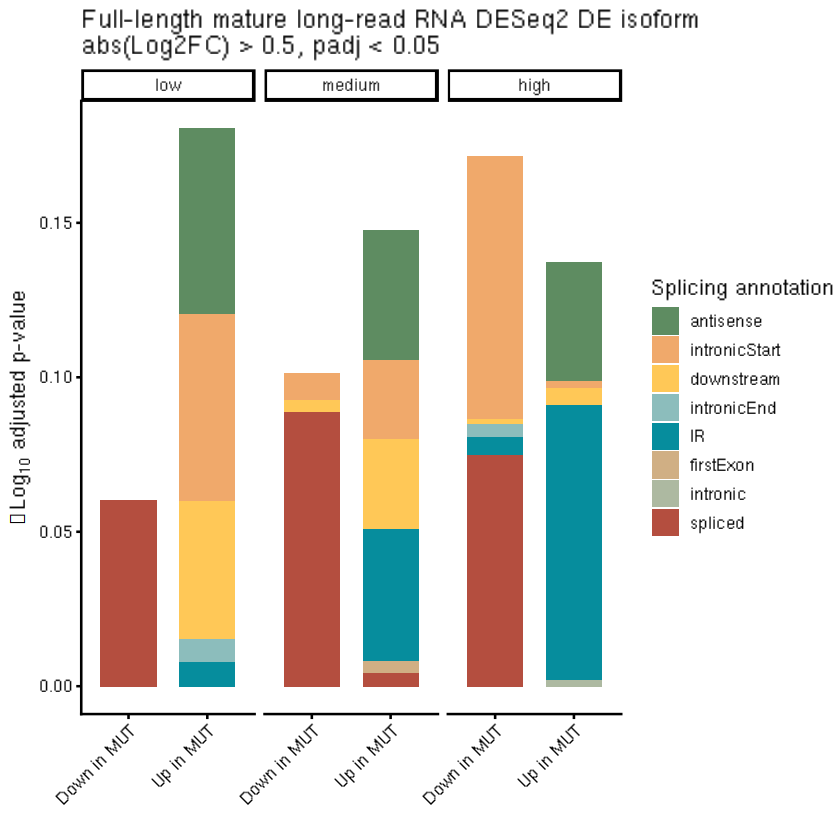

In [310]:
p1<- df2 %>%
    mutate(feature_id = factor(feature_id, levels = iso_levels),
           labels = factor(labels, levels = c("Down in MUT", "Up in MUT", "Not sig"))) %>% 
    ggplot(aes(x = labels, y = p, fill = feature_id)) +
    geom_bar(stat='identity', position = "stack", width=0.7) +
    scale_fill_manual(values = mcolors) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
    labs(x = "", y = expression(-Log[10] * " adjusted p-value"), 
         title = "Full-length mature long-read RNA DESeq2 DE isoform\nabs(Log2FC) > 0.5, padj < 0.05", fill = "Splicing annotation")  +
    facet_wrap(vars(class), ncol = 3)

ggsave("../figures/Supp_mature_rna_splicing_percentage_of_isoform_by_expr_with_sig.pdf", p1, width = 6, height = 3)

p2<- df2 %>%
    mutate(feature_id = factor(feature_id, levels = iso_levels),
           labels = factor(labels, levels = c("Down in MUT", "Up in MUT", "Not sig"))) %>% 
    filter(labels != "Not sig") %>% 
    ggplot(aes(x = labels, y = p, fill = feature_id)) +
    geom_bar(stat='identity', position = "stack", width=0.7) +
    scale_fill_manual(values = mcolors) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
    labs(x = "", y = expression(-Log[10] * " adjusted p-value"), 
         title = "Full-length mature long-read RNA DESeq2 DE isoform\nabs(Log2FC) > 0.5, padj < 0.05", fill = "Splicing annotation") +
    facet_wrap(vars(class), ncol = 3) 
p2
ggsave("../figures/Supp_mature_rna_splicing_percentage_of_isoform_by_expr.pdf", p2, width = 6, height = 3)

In [94]:
## fraction of genes with DE isoforms in splicing

In [311]:
all_genes<- de_df$gene_id %>% sort() %>% unique()
ds_genes<- de_df %>% distinct(labels, gene_id) %>% filter(labels != "Not sig") %>% pull(gene_id) %>% sort() %>% unique()
ds_genes
write.table(x = ds_genes, file = "../data/13_mature_rna_splicing_all_DE_isoforms_geneid.tsv", sep = "\t", quote = F, col.names = F, row.names = F)

[1] "ACT1"      "AIM11"     "APE2"      "APS3"      "ARF2"      "ARP2"     
  [7] "ARP9"      "BET1"      "BMH2"      "BOS1"      "CGI121"    "CIN2"     
 [13] "CMC2"      "COF1"      "COX5B"     "CPT1"      "DBP2"      "DID4"     
 [19] "DTD1"      "DYN2"      "EPT1"      "ERV1"      "ERV41"     "GIM4"     
 [25] "GOT1"      "HFM1"      "HNT1"      "HOP2"      "HPC2"      "HRB1"     
 [31] "IST1"      "KIN28"     "LSB3"      "LSM2"      "MAF1"      "MMS2"     
 [37] "MOB2"      "MPT5"      "MRPL44"    "MTR2"      "NHP6B"     "NSP1"     
 [43] "NYV1"      "OM14"      "OST5"      "PCC1"      "POP8"      "PRE3"     
 [49] "PTC7"      "RAD14"     "RBS1"      "REC107"    "RIM1"      "RPL13A"   
 [55] "RPL13B"    "RPL14B"    "RPL16A"    "RPL17A"    "RPL17B"    "RPL18A"   
 [61] "RPL18B"    "RPL19A"    "RPL19B"    "RPL20A"    "RPL20B"    "RPL21B"   
 [67] "RPL22B"    "RPL23A"    "RPL23B"    "RPL24B"    "RPL25"     "RPL26A"   
 [73] "RPL27A"    "RPL27B"    "RPL28"     "RPL29"     "RPL2A"     "RPL2B"    
 [79] "RPL30"     "RPL31A"    "RPL31B"    "RPL33B"    "RPL34A"    "RPL34B"   
 [85] "RPL35B"    "RPL36A"    "RPL37A"    "RPL37B"    "RPL40A"    "RPL40B"   
 [91] "RPL42A"    "RPL42B"    "RPL43A"    "RPL43B"    "RPL6B"     "RPO26"    
 [97] "RPP1B"     "RPS0A"     "RPS10A"    "RPS10B"    "RPS11A"    "RPS13"    
[103] "RPS14A"    "RPS14B"    "RPS16A"    "RPS16B"    "RPS17A"    "RPS17B"   
[109] "RPS18B"    "RPS19A"    "RPS21A"    "RPS21B"    "RPS23A"    "RPS25A"   
[115] "RPS25B"    "RPS26A"    "RPS26B"    "RPS27A"    "RPS27B"    "RPS29A"   
[121] "RPS29B"    "RPS30A"    "RPS30B"    "RPS4B"     "RPS6A"     "RPS6B"    
[127] "RPS7B"     "RPS8B"     "RPS9B"     "RUB1"      "SAR1"      "SCS22"    
[133] "SEC17"     "SFT1"      "SNC1"      "SNR17A"    "SPT14"     "SRB2"     
[139] "SRC1"      "SUS1"      "TAD3"      "TMA20"     "TUB3"      "UBC13"    
[145] "UBC8"      "VMA10"     "VMA9"      "VPS75"     "YBL059W"   "YBR255C-A"
[151] "YDL012C"   "YGR001C"   "YHR097C"   "YIP3"      "YJR079W"   "YNL050C"  
[157] "YOS1"      "YPR063C"   "YPR170W-B" "YSC84"     "YSF3"

In [315]:
ds_genes_nascent<- read.table(file = "../data/13_nascent_rna_splicing_all_DE_isoforms_geneid.tsv", sep = "\t") %>% pull(V1)

In [317]:
library(ggVennDiagram)


Attaching package: ‘ggVennDiagram’


The following object is masked from ‘package:tidyr’:

    unite




In [338]:
length(ds_genes)
length(ds_genes_nascent)
length(intersect(ds_genes, ds_genes_nascent))
all_ds_genes<- c(ds_genes, ds_genes_nascent) %>% sort() %>% unique()

[1] 161

[1] 150

[1] 98

In [370]:
gene_list <- list(
  "Mature RNA" = ds_genes, 
  "Nascent RNA" = ds_genes_nascent
)

p <- ggVennDiagram(gene_list, 
                   label = "both",
                   label_alpha = 0,
                   edge_size = 1, font_size  = 10) +
    theme(legend.position = "right",
        legend.text = element_text(size = 10)) +
    scale_fill_distiller(palette = "RdBu") +
    coord_flip()
ggsave('../figures/Supp_rna_splicing_venn_diagram.pdf', p, width = 4, height = 2.5)

Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.


Joining with `by = join_by(class)`


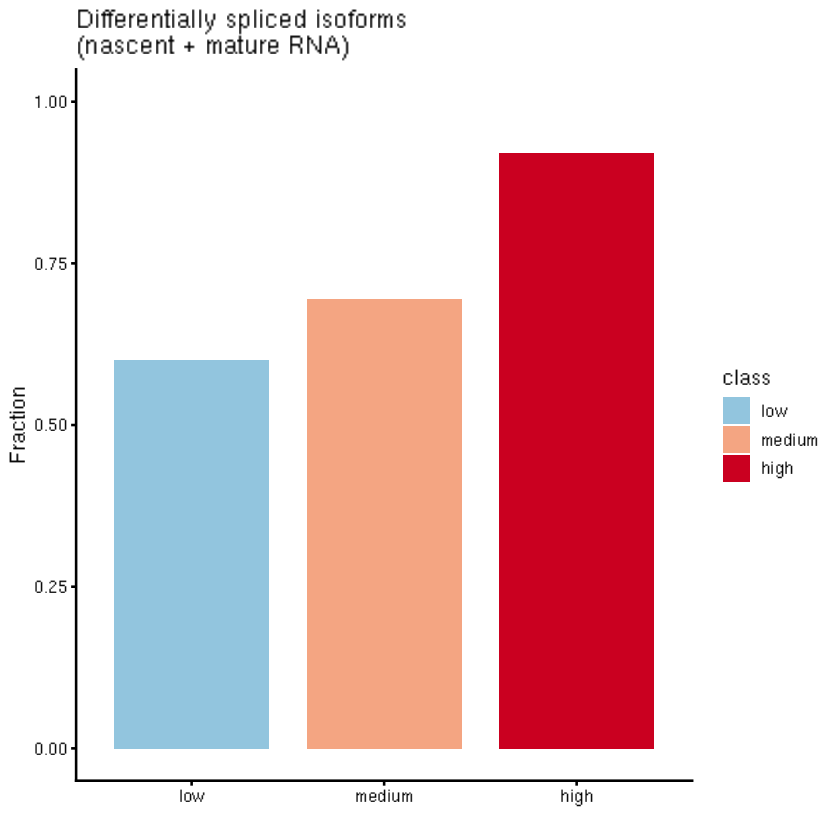

In [371]:
df<- final_iso_tb %>% rownames_to_column("rownames") %>%  distinct(gene_id, class)
df$splicing_de = "Not sig"
df[df$gene_id %in% all_ds_genes, 'splicing_de'] = "DE"

df<- df %>% count(class, name = 'total') %>% 
    left_join(count(df, class, splicing_de)) %>% 
    mutate(frac = n/total)

df$class<- factor(df$class, levels = c('low', 'medium', 'high'))

mcol = c("#fb8072", "")
names(mcol) = c("DE", "Not sig")

mcolors <- c("#92c5de", "#f4a582", "#ca0020")
names(mcolors)<- c("low", "medium", "high")

df %>% 
    filter(splicing_de == "DE") %>% 
    ggplot(aes(x = class, y = frac, fill = class)) +
    geom_bar(stat = "identity", width = 0.8) +
    scale_fill_manual(values = class_colors) +
    labs(x = '', y = "Fraction", title = "Differentially spliced isoforms\n(nascent + mature RNA)") +
    ylim(0, 1)

ggsave('../figures/Supp_mature_rna_splicing_fraction_of_de_genes_by_expr.pdf', width = 4, height = 3.5)

## genes with alternative splicing vs genes with chromatin change

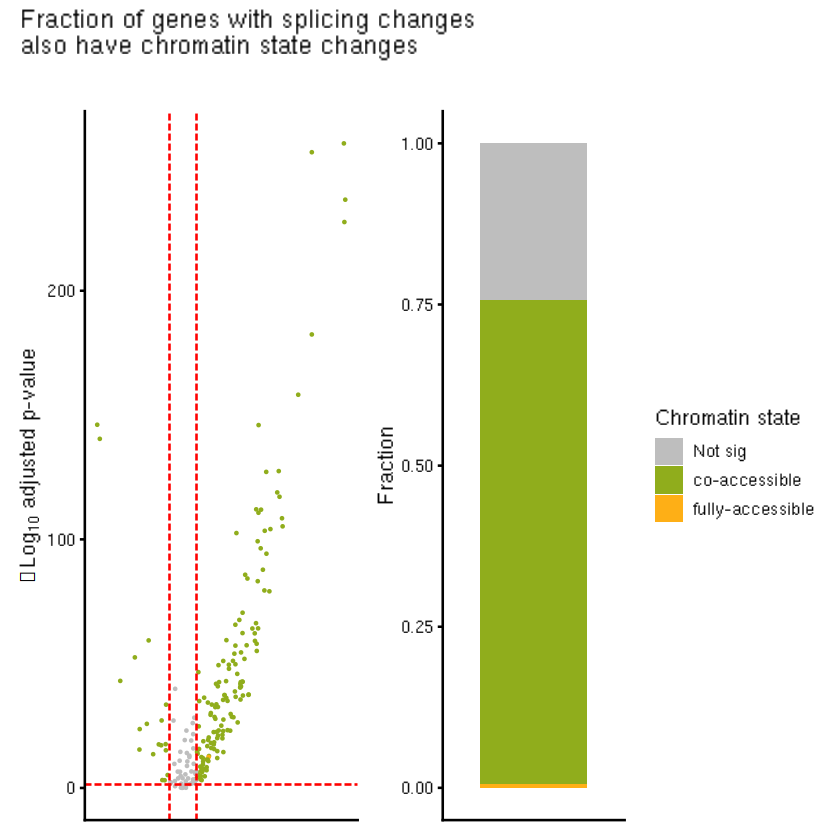

In [433]:
diff_nuc<- read.table(file = '../data/5_chromatin_diff_chrom_results.tsv', sep = '\t', header = T, row.names = 1) %>% 
    filter(gene_id %in% final_iso_tb$gene_id)

df<- diff_nuc[!diff_nuc %>% arrange(gene_id, labels) %>% pull(gene_id) %>% duplicated(), ]

df$splicing_change = "Not sig"
df[df$gene_id %in% all_ds_genes, "splicing_change"] = "DE"

mcolors <- polychrome()[c(7, 10, 8, 6, 15)]
names(mcolors) <- c('fully-accessible', 'co-accessible', 'promoter-accessible', 'intragenic-accessible', 'fully-nucleosomal')
mcolors_withsig = c(mcolors, "gray")
names(mcolors_withsig)<- c(names(mcolors), "Not sig")


mcol = c("#fb8072", "grey20")
names(mcol) = c("DE", "Not sig")

delta_cutoff = 0.05
p1<- df %>%
    filter(splicing_change != "Not sig") %>% 
    ggplot(aes(x = delta, y = -log10(pval_adj))) +
    geom_point(aes(color = type), size = 0.2) +
    labs(x = expression("Delta usage"),y = expression(-Log[10] * " adjusted p-value"), 
         title ="", 
         color = "Chromatin state") +
    geom_vline(xintercept = delta_cutoff, color = 'red', linetype = "longdash") +
    geom_vline(xintercept = -delta_cutoff, color = 'red', linetype = "longdash") +
    geom_hline(yintercept = -log10(0.05), color = 'red', linetype = "longdash") +
    scale_color_manual(values = mcolors_withsig) +
    guides(color = guide_legend(override.aes = list(size = 3))) +
    theme(legend.position = "none",     
          axis.title.x = element_blank(), 
          axis.text.x = element_blank(),
          axis.ticks.x = element_blank())

p2<- df %>% 
    select(gene_id, type, class, splicing_change) %>% 
    mutate(type = factor(type, levels = rev(names(mcolors_withsig)))) %>% 
    filter(splicing_change == "DE") %>% 
    ggplot(aes(x = splicing_change, fill = type)) +
    geom_bar(stat = "count", position = "fill", width = 0.7) +
    labs(x = "Splicing Change", y = "Fraction", fill = "Chromatin state",
        title = "") +
    scale_fill_manual(values = mcolors_withsig) +
    theme(axis.title.x = element_blank(), 
          axis.text.x = element_blank(),
          axis.ticks.x = element_blank())

p<- wrap_plots(c(p1, p2), ncol = 2, widths = c(0.6, 0.4)) + 
    plot_annotation("Fraction of genes with splicing changes\nalso have chromatin state changes")

p
ggsave('../figures/Supp_rna_splicing_fraction_of_AS_genes_chromatin_state.pdf', p, width = 6, height = 3.5)